# MUSK — Multimodal Transformer with Unified MaSK Modeling (Nature 2025)

This notebook evaluates `xiangjx/musk` (HuggingFace) on the week1 **pathology** datasets.

**What is MUSK?**  
MUSK (*Multimodal transformer with Unified maSK modeling*) is a vision-language foundation model for **precision oncology** published in *Nature* (2025) by Xiang, Wang et al. from Stanford University and Harvard University. It was pre-trained on **50 million pathology images** and **1 billion pathology-related text tokens** using a novel unified masked modeling strategy that combines masked image modeling, masked language modeling, and image-text contrastive learning.

MUSK achieves state-of-the-art performance across 23 patch-level and slide-level benchmarks including cross-modal retrieval, zero-shot classification, visual question answering, and outcome prediction (melanoma relapse, pan-cancer prognosis, immunotherapy response).

**Model specs:**
- Architecture: ViT-Large/16 (image) + XLM-RoBERTa (text), unified multiway transformer
- Input: 384×384 pixels, Inception mean/std normalisation
- Training: 50M pathology images + 1B text tokens (masked + contrastive)
- HuggingFace: `xiangjx/musk` (gated — requires accepted terms + HF token)
- GitHub: https://github.com/lilab-stanford/MUSK
- Paper: [Xiang et al., Nature 2025](https://www.nature.com/articles/s41586-024-08378-w)

## Model Comparison

| Aspect | MUSK | BiomedCLIP | CONCH |
|---|---|---|---|
| Model type | Unified masked + contrastive | Contrastive (CLIP) | Contrastive (CLIP) |
| Training images | **50M pathology** | 15M pan-medical | 1.17M histopathology |
| Text tokens | **1B pathology text** | PMC captions only | Caption text only |
| Domain | **Pathology only** | Pan-medical | Histopathology only |
| Input size | 384×384 | 224×224 | 448×448 |
| Architecture | ViT-L/16 (large) | ViT-B/16 (base) | ViT-B/16 (base) |
| API | Custom `musk` + `timm` | `open_clip` | Custom `conch` |

## Domain Scope

MUSK is trained **exclusively on pathology data**. Radiology images (CT, MRI) are out-of-domain. The appropriate week1 datasets are:

| Dataset | Included | Reason |
|---|---|---|
| IQ-OTH/NCCD (Chest CT) | No | Radiology — out of domain |
| Spinal CT (DICOM) | No | Radiology — out of domain |
| Quilt1M ×4 | **Yes** | H&E histopathology — core training domain |
| PKG HistologyHSI-GB | **Yes** | Brain tumor histopathology — in domain |
| OASIS-1 (Brain MRI) | No | Radiology — out of domain |

## Tasks Per Sample
1. **Zero-shot classification** — rank pathology labels by softmax similarity.
2. **Image–text similarity** — cosine similarity against ground-truth CSV caption (Quilt1M only).

In [5]:
import warnings
import logging

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
logging.getLogger("transformers").setLevel(logging.ERROR)

In [6]:
import ast
import os
from pathlib import Path

import numpy as np
import pandas as pd
import spectral.io.envi as envi
import torch
import torchvision
from huggingface_hub import hf_hub_download
from PIL import Image
from timm.data.constants import IMAGENET_INCEPTION_MEAN, IMAGENET_INCEPTION_STD
from timm.models import create_model

from musk import utils, modeling  # noqa: F401 — registers musk_large_patch16_384

HF_TOKEN = os.environ.get("HF_TOKEN")

# MUSK uses float16 on CUDA; float32 on MPS/CPU (bfloat16 not well-supported by all ops)
device = "mps" if torch.backends.mps.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32
print(f"Using device: {device} | dtype: {dtype}")

Using device: mps | dtype: torch.float32


## Loading MUSK

MUSK uses a custom loading path (not standard `AutoModel`):
1. `timm.models.create_model("musk_large_patch16_384")` — instantiates the architecture (registered by `musk.modeling`).
2. `utils.load_model_and_may_interpolate("hf_hub:xiangjx/musk", ...)` — downloads `model.safetensors` from HuggingFace and loads weights.
3. The XLM-RoBERTa tokenizer `tokenizer.spm` is also downloaded from `xiangjx/musk`.

For zero-shot tasks, the key parameters are:
- `with_head=True` — use the contrastive projection head (required for zero-shot).
- `out_norm=True` — L2-normalise the output embeddings.
- `ms_aug=False` — disable multi-scale augmentation (only needed for linear probe/MIL).
- `return_global=True` — return only the [CLS] token embedding, not patch tokens.

In [7]:
# Step 1: Instantiate MUSK-large architecture
model = create_model("musk_large_patch16_384")

# Step 2: Download and load weights from HuggingFace
# First run downloads ~1.2 GB model.safetensors to ~/.cache/
utils.load_model_and_may_interpolate(
    ckpt_path="hf_hub:xiangjx/musk",
    model=model,
    model_key="model|module",
    model_prefix="",
)
model = model.to(device=device, dtype=dtype)
model.eval()

print("MUSK model loaded successfully.")
print("  Architecture: ViT-Large/16 unified multiway transformer")
print("  Training    : 50M pathology images + 1B text tokens")
print(f"  Device      : {device} | dtype: {dtype}")

Load ckpt from hf_hub:xiangjx/musk
MUSK model loaded successfully.
  Architecture: ViT-Large/16 unified multiway transformer
  Training    : 50M pathology images + 1B text tokens
  Device      : mps | dtype: torch.float32


In [8]:
# Step 3: Download tokenizer.spm and load via SentencePiece directly.
#
# Transformers 5.x changed XLMRobertaTokenizer to use a Rust tokenizers backend
# that cannot read raw .spm files (TypeError: Can't extract str to Vec).
# We wrap SentencePieceProcessor to expose the same interface that
# utils.xlm_tokenizer() expects: .encode(), .bos_token_id, .eos_token_id, .pad_token_id.
import sentencepiece as spm

tokenizer_path = hf_hub_download(
    repo_id="xiangjx/musk",
    filename="tokenizer.spm",
    token=HF_TOKEN,
)

class _SPTokenizer:
    """
    Thin wrapper around SentencePieceProcessor that mimics the
    XLMRobertaTokenizer interface used by musk.utils.xlm_tokenizer():

        tokens = tokenizer.encode(text)   # list[int] with bos+eos
        tokens = tokens[1:-1]             # strip bos/eos
        ...
        [tokenizer.bos_token_id] + tokens + [tokenizer.eos_token_id]
        ... + [tokenizer.pad_token_id] * padding
    """
    def __init__(self, spm_path: str):
        self._sp = spm.SentencePieceProcessor()
        self._sp.Load(spm_path)
        self.bos_token_id = self._sp.bos_id()   # <s>   — typically 0
        self.eos_token_id = self._sp.eos_id()   # </s>  — typically 2
        self.pad_token_id = 1                   # <pad> — XLM-R standard

    def encode(self, text: str) -> list[int]:
        """Return IDs with bos and eos prepended/appended (same as XLMRobertaTokenizer default)."""
        ids = self._sp.encode_as_ids(text)
        return [self.bos_token_id] + ids + [self.eos_token_id]

tokenizer = _SPTokenizer(tokenizer_path)
print(f"Tokenizer loaded from: {tokenizer_path}")
print(f"  bos_token_id={tokenizer.bos_token_id}  eos_token_id={tokenizer.eos_token_id}  pad_token_id={tokenizer.pad_token_id}")
print(f"  Vocab size: {tokenizer._sp.GetPieceSize()}")

# Step 4: Image preprocessing — 384×384, Inception mean/std (NOT ImageNet)
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(384, interpolation=3, antialias=True),
    torchvision.transforms.CenterCrop((384, 384)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=IMAGENET_INCEPTION_MEAN, std=IMAGENET_INCEPTION_STD),
])
print(f"\nImage transform: Resize→384, CenterCrop→384×384, Inception normalisation")
print(f"  mean={IMAGENET_INCEPTION_MEAN}  std={IMAGENET_INCEPTION_STD}")

Tokenizer loaded from: /Users/mfanti/.cache/huggingface/hub/models--xiangjx--musk/snapshots/de1ffed28608c197d2903f6fa42b491a3fbf0fb8/tokenizer.spm
  bos_token_id=1  eos_token_id=2  pad_token_id=1
  Vocab size: 64000

Image transform: Resize→384, CenterCrop→384×384, Inception normalisation
  mean=(0.5, 0.5, 0.5)  std=(0.5, 0.5, 0.5)


## Zero-shot Label Sets

MUSK uses simple pathology-style text prompts (e.g., `"histopathology image of glioblastoma"`), consistent with the model's training on pathology image-caption pairs.

- **Quilt1M**: unique sub-specialties from `quilt_1M_lookup.csv` `pathology` column.
- **PKG (glioblastoma)**: brain tumor classification categories.

In [9]:
BRAIN_PATHOLOGY_LABELS = [
    "glioblastoma multiforme",
    "normal brain tissue",
    "low-grade glioma",
    "meningioma",
    "brain metastasis",
    "astrocytoma",
    "oligodendroglioma",
    "necrotic tumor tissue",
    "tumor infiltrating lymphocytes",
]

# MUSK prompt template — simple pathology description style
PATHOLOGY_TEMPLATE = "histopathology image of {}"

# Quilt1M CSV categories
CSV_PATH = Path("../week1/data/quilt_1M_lookup.csv")
df_quilt = pd.read_csv(CSV_PATH, low_memory=False)

def parse_pathology_list(val) -> list[str]:
    if pd.isna(val) or str(val).strip() in ("", "nan", "[]"):
        return []
    try:
        parsed = ast.literal_eval(str(val))
        return [s.strip() for s in parsed if isinstance(s, str) and s.strip()]
    except (ValueError, SyntaxError):
        return []

QUILT_CATEGORIES = sorted(set(
    cat for cats in df_quilt["pathology"].apply(parse_pathology_list) for cat in cats
))
print(f"Quilt1M categories : {len(QUILT_CATEGORIES)} (from CSV)")
print(f"Brain tumor labels : {len(BRAIN_PATHOLOGY_LABELS)}")
print(f"Prompt template    : '{PATHOLOGY_TEMPLATE}'")
print("\nQuilt1M categories:", QUILT_CATEGORIES)

Quilt1M categories : 18 (from CSV)
Brain tumor labels : 9
Prompt template    : 'histopathology image of {}'

Quilt1M categories: ['Bone', 'Breast', 'Cardiac', 'Cytopathology', 'Dermatopathology', 'Endocrine', 'Gastrointestinal', 'Genitourinary', 'Gynecologic', 'Head and Neck', 'Hematopathology', 'Neuropathology', 'Ophthalmic', 'Others', 'Pediatric', 'Pulmonary', 'Renal', 'Soft tissue']


In [10]:
def load_image(path: Path) -> Image.Image:
    return Image.open(path).convert("RGB")

def load_hsi_pseudo_rgb(hdr_path: Path) -> Image.Image:
    """
    ENVI hyperspectral cube → pseudo-RGB by selecting bands at 650/550/450 nm.
    Each band slice from spectral.load() is (rows, cols, 1); squeeze before stacking.
    """
    img = envi.open(str(hdr_path))
    wavelengths = np.array([float(w) for w in img.metadata["wavelength"]])
    cube = img.load()
    def norm(arr): return ((arr - arr.min()) / (arr.max() - arr.min() + 1e-9) * 255).astype(np.uint8)
    rgb = np.stack([norm(np.squeeze(cube[:, :, int(np.argmin(np.abs(wavelengths - t)))])) for t in [650, 550, 450]], axis=2)
    return Image.fromarray(rgb)

LOADER_MAP = {"image": load_image, "hsi": load_hsi_pseudo_rgb}
print("Loaders ready:", list(LOADER_MAP.keys()))

Loaders ready: ['image', 'hsi']


In [11]:
def encode_image(pil_img: Image.Image) -> torch.Tensor:
    """
    Encode a PIL image with MUSK.
    - with_head=True: use contrastive projection head (required for zero-shot).
    - out_norm=True: L2-normalise output.
    - ms_aug=False: no multi-scale (CLS token for zero-shot, not patch features).
    Returns shape (1, D).
    """
    tensor = transform(pil_img.convert("RGB")).unsqueeze(0).to(device, dtype=dtype)
    with torch.inference_mode():
        emb = model(
            image=tensor,
            with_head=True,
            out_norm=True,
            ms_aug=False,
            return_global=True,
        )[0]  # returns (image_emb, text_emb); [0] = image
    return emb  # (1, D)


def encode_texts(texts: list[str]) -> torch.Tensor:
    """
    Encode a list of text strings with MUSK's XLM-RoBERTa text encoder.
    xlm_tokenizer() operates on a single string; we iterate and batch.
    Returns shape (N, D).
    """
    all_ids, all_pads = [], []
    for t in texts:
        ids, pad = utils.xlm_tokenizer(t, tokenizer, max_len=100)
        all_ids.append(ids)
        all_pads.append(pad)
    txt_ids  = torch.tensor(all_ids,  dtype=torch.long).to(device)  # (N, 100)
    pad_mask = torch.tensor(all_pads, dtype=torch.long).to(device)  # (N, 100)
    with torch.inference_mode():
        emb = model(
            text_description=txt_ids,
            padding_mask=pad_mask,
            with_head=True,
            out_norm=True,
            ms_aug=False,
            return_global=True,
        )[1]  # [1] = text embeddings
    return emb  # (N, D)


def zero_shot_classify(image_emb: torch.Tensor, labels: list[str], template: str, top_k: int = 5) -> list[tuple[str, float]]:
    prompts = [template.format(l) for l in labels]
    text_embs = encode_texts(prompts)  # (N, D)
    # Cast image_emb to float32 for matmul compatibility on MPS
    probs = (100.0 * image_emb.float() @ text_embs.float().T).softmax(dim=-1)[0].cpu().numpy()
    return sorted(zip(labels, probs.tolist()), key=lambda x: x[1], reverse=True)[:top_k]


def image_text_similarity(image_emb: torch.Tensor, caption: str) -> float:
    cap_emb = encode_texts([caption])  # (1, D)
    return round((image_emb.float() * cap_emb.float()).sum().item(), 4)


print("Helpers defined.")

Helpers defined.


## Dataset 1: Quilt1M — H&E Histopathology (4 subsets)

One H&E image per Quilt1M source:

| Subset | Source | Image | Known pathology |
|---|---|---|---|
| `pubmed` | PubMed open-access figures | `c901a42b…_1.jpg` | IDH1 immunocytochemistry, osteosarcoma cell lines |
| `quilt` | YouTube pathology videos | `dTr3MNl1…jpg` | Nephrogenic systemic fibrosis, spindle cells |
| `openpath` | Twitter / OpenPath | `994701…_0.jpg` | Peritoneal biopsy |
| `laion` | LAION web scrape | `000040…jpg` | Web-sourced histopathology |

Labels are all unique `pathology` column categories from `quilt_1M_lookup.csv`. Image–caption cosine similarity is reported against the ground-truth CSV caption. MUSK's 50M pathology training set is expected to produce strong alignment for H&E images.

## Dataset 2: PKG HistologyHSI-GB — Glioblastoma Hyperspectral

Hyperspectral cube (ENVI BIL format) synthesised into pseudo-RGB by selecting bands at 650/550/450 nm. MUSK was trained on standard H&E pathology images, not hyperspectral data. This tests whether the visual appearance of the pseudo-RGB approximation is sufficient for MUSK to extract meaningful pathology features. Glioblastoma is a common brain tumor in MUSK's training distribution.

In [12]:
BASE = Path("../week1/data")

def get_quilt_caption(filename: str) -> str:
    matches = df_quilt[df_quilt["image_path"] == filename]
    if matches.empty: return ""
    cap = matches.iloc[0]["caption"]
    return "" if pd.isna(cap) else str(cap)

LOCAL_SAMPLES = [
    {"name": "Quilt1M — PubMed",            "path": BASE/"Quilt1M_pubmed/c901a42b-0ab9-45d9-809d-dd646effcf9c_1.jpg", "type": "image", "labels": QUILT_CATEGORIES,      "caption_file": "c901a42b-0ab9-45d9-809d-dd646effcf9c_1.jpg"},
    {"name": "Quilt1M — YouTube (quilt)",   "path": BASE/"Quilt1M_quilt/dTr3MNl1FxE_image_c54e9a8d-9348-456a-9645-3b8921eb0b79.jpg", "type": "image", "labels": QUILT_CATEGORIES, "caption_file": "dTr3MNl1FxE_image_c54e9a8d-9348-456a-9645-3b8921eb0b79.jpg"},
    {"name": "Quilt1M — OpenPath (Twitter)","path": BASE/"Quilt1M_openpath/994701482116173824_0.jpg", "type": "image", "labels": QUILT_CATEGORIES, "caption_file": "994701482116173824_0.jpg"},
    {"name": "Quilt1M — LAION",             "path": BASE/"Quilt1M_laion/00004000040081.jpg",           "type": "image", "labels": QUILT_CATEGORIES, "caption_file": "00004000040081.jpg"},
    {"name": "PKG HistologyHSI-GB — P1",    "path": BASE/"PKG_HistologyHSI_GB/P1/ROI_01_C01_T/raw.hdr", "type": "hsi",   "labels": BRAIN_PATHOLOGY_LABELS, "caption_file": None},
]

print(f"Defined {len(LOCAL_SAMPLES)} samples (pathology domain only).")
for s in LOCAL_SAMPLES:
    print(f"  [{'OK' if Path(s['path']).exists() else 'MISSING'}] {s['name']}")

Defined 5 samples (pathology domain only).
  [OK] Quilt1M — PubMed
  [OK] Quilt1M — YouTube (quilt)
  [OK] Quilt1M — OpenPath (Twitter)
  [OK] Quilt1M — LAION
  [OK] PKG HistologyHSI-GB — P1



  Quilt1M — PubMed
  [TASK 1] Zero-shot classification (top-5):
    1. Ophthalmic                               54.76%  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    2. Gastrointestinal                         16.85%  ███████████████████████████████████████████████████████████████████
    3. Genitourinary                            10.07%  ████████████████████████████████████████
    4. Bone                                      4.83%  ███████████████████
    5. Pulmonary                                 4.65%  ██████████████████
  [TASK 2] Image–caption cosine similarity: 0.4740
           Caption: "The immunocytochemistry of IDH1 in MG63 and U2OS. IDH1 is specifically detected in the cytoplasm of "


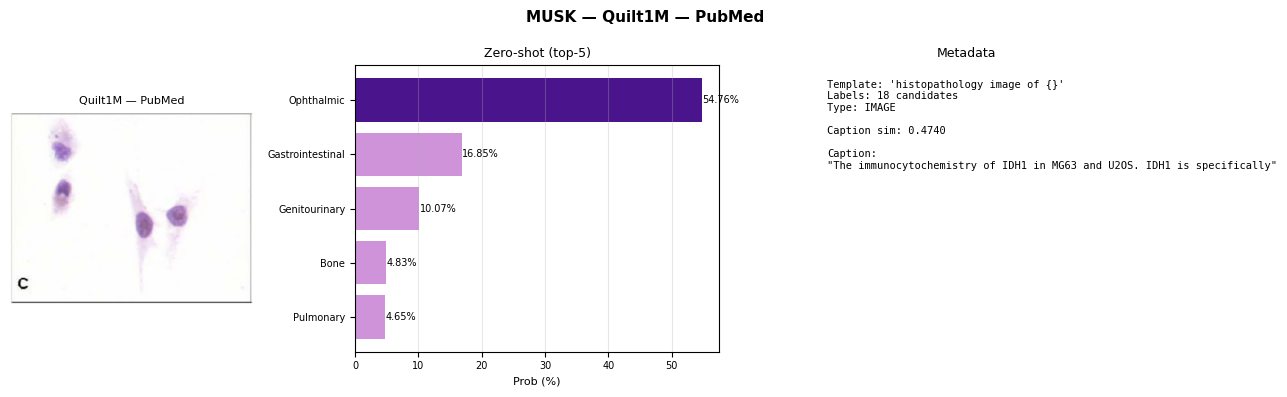


  Quilt1M — YouTube (quilt)
  [TASK 1] Zero-shot classification (top-5):
    1. Renal                                    29.39%  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    2. Pulmonary                                18.93%  ███████████████████████████████████████████████████████████████████████████
    3. Pediatric                                18.37%  █████████████████████████████████████████████████████████████████████████
    4. Endocrine                                12.19%  ████████████████████████████████████████████████
    5. Others                                    6.58%  ██████████████████████████
  [TASK 2] Image–caption cosine similarity: 0.3804
           Caption: "Nephrogenic systemic fibrosis is a fibrotic disorder with deep involvement that goes down to the fas"


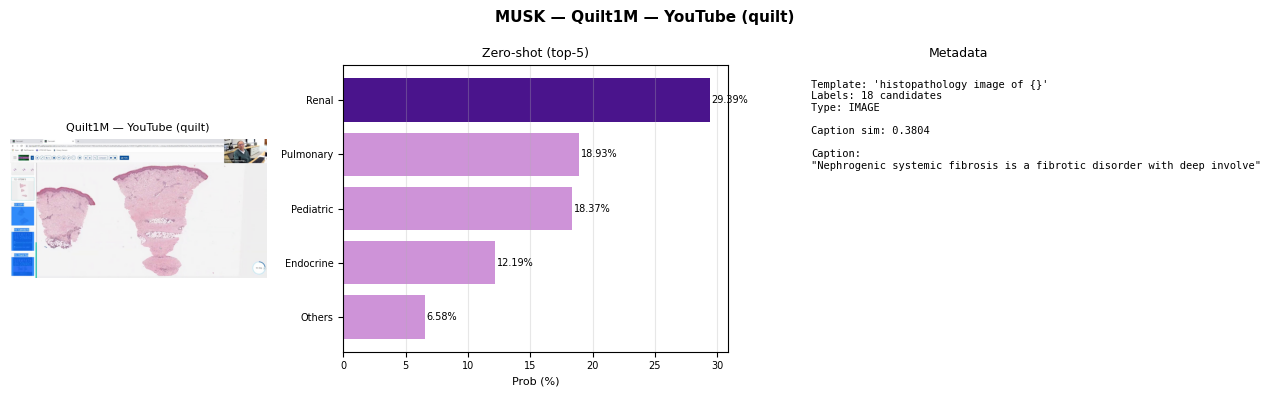


  Quilt1M — OpenPath (Twitter)
  [TASK 1] Zero-shot classification (top-5):
    1. Genitourinary                            69.32%  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    2. Pulmonary                                14.48%  █████████████████████████████████████████████████████████
    3. Gynecologic                               7.41%  █████████████████████████████
    4. Ophthalmic                                2.77%  ███████████
    5. Bone                                      2.69%  ██████████
  [TASK 2] Image–caption cosine similarity: 0.4614
           Caption: "Peritoneum, Day 4 These two biopsies (1 & 2) were taken from the same patient. What is your DailyDx "


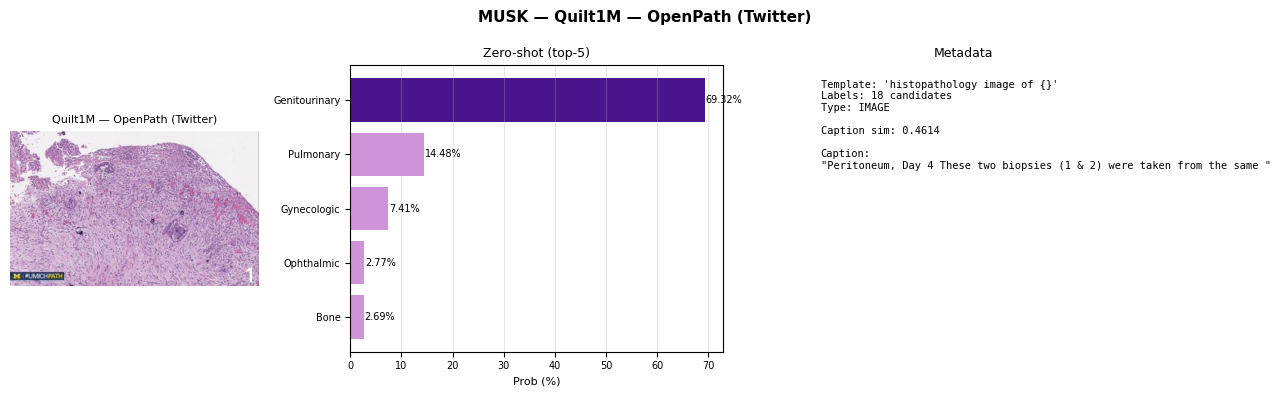


  Quilt1M — LAION
  [TASK 1] Zero-shot classification (top-5):
    1. Ophthalmic                               82.18%  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    2. Hematopathology                           5.30%  █████████████████████
    3. Bone                                      3.34%  █████████████
    4. Dermatopathology                          2.52%  ██████████
    5. Breast                                    2.18%  ████████
  [TASK 2] Image–caption cosine similarity: 0.4446
           Caption: "Cytosolic Sulfotransferase 1A1 /SULT1A1 Antibody"


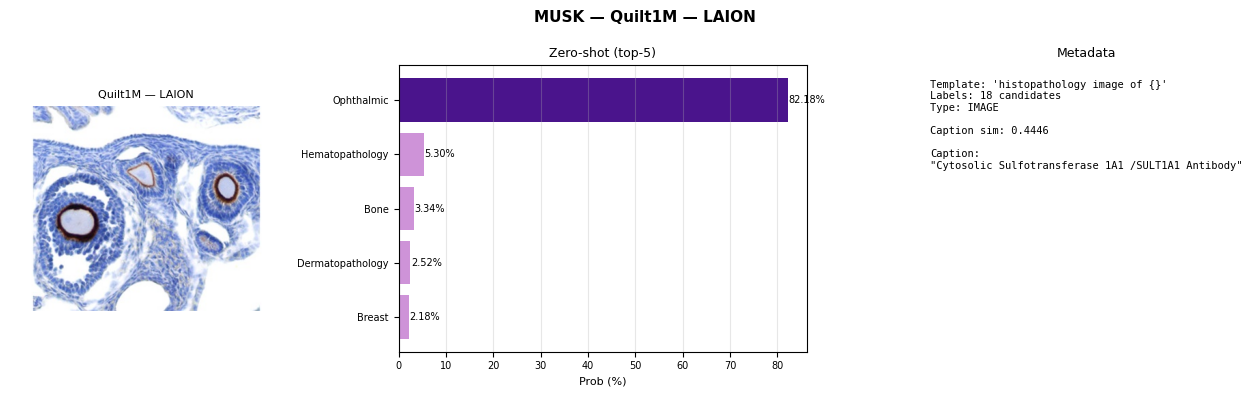


  PKG HistologyHSI-GB — P1
  [TASK 1] Zero-shot classification (top-5):
    1. brain metastasis                         42.37%  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    2. meningioma                               34.02%  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    3. astrocytoma                               8.50%  ██████████████████████████████████
    4. normal brain tissue                       4.75%  ██████████████████
    5. low-grade glioma                          4.45%  █████████████████
  [TASK 2] No ground-truth caption (PKG sample) — skipped


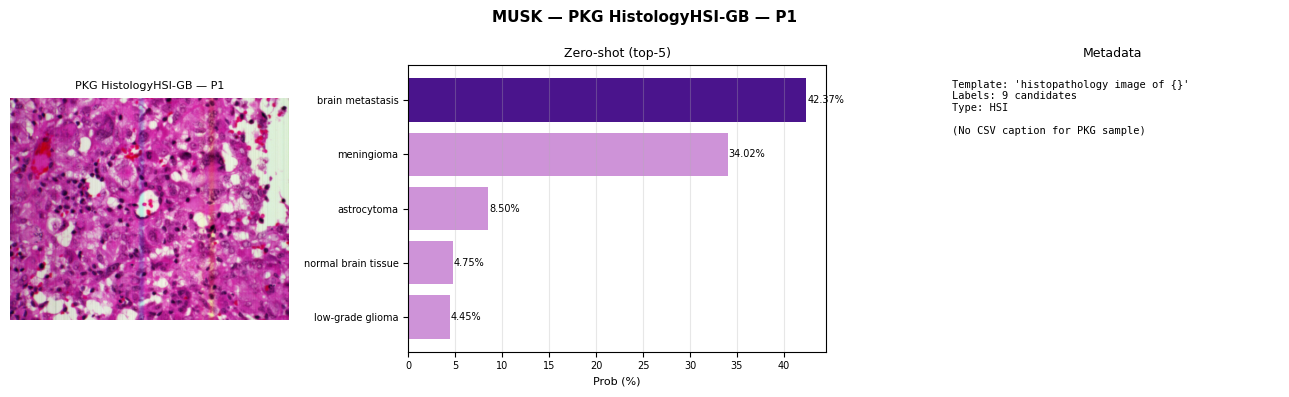

In [13]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

RESULTS = []

for sample in LOCAL_SAMPLES:
    img_path = Path(sample["path"])
    print(f"\n{'='*65}")
    print(f"  {sample['name']}")
    if not img_path.exists():
        print(f"  [ERROR] Not found: {img_path}")
        continue

    pil_img = LOADER_MAP[sample["type"]](img_path)
    image_emb = encode_image(pil_img)

    # Task 1: zero-shot classification
    top5 = zero_shot_classify(image_emb, sample["labels"], PATHOLOGY_TEMPLATE)
    print("  [TASK 1] Zero-shot classification (top-5):")
    for rank, (label, prob) in enumerate(top5, 1):
        bar = "█" * int(prob * 400)
        print(f"    {rank}. {label:<40} {prob*100:5.2f}%  {bar}")

    # Task 2: image-text similarity
    similarity = None
    caption = get_quilt_caption(sample["caption_file"]) if sample["caption_file"] else ""
    if caption:
        similarity = image_text_similarity(image_emb, caption)
        print(f"  [TASK 2] Image–caption cosine similarity: {similarity:.4f}")
        print(f"           Caption: \"{caption[:100]}\"")
    else:
        print("  [TASK 2] No ground-truth caption (PKG sample) — skipped")

    # Visualisation
    fig = plt.figure(figsize=(13, 4))
    gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 1.5, 1.2])

    ax_img = fig.add_subplot(gs[0])
    ax_img.imshow(pil_img); ax_img.set_title(sample["name"], fontsize=8); ax_img.axis("off")

    ax_bar = fig.add_subplot(gs[1])
    lbls = [t[0] for t in top5]; probs = [t[1]*100 for t in top5]
    ax_bar.barh(lbls[::-1], probs[::-1], color=["#4A148C" if i==0 else "#CE93D8" for i in range(5)][::-1])
    ax_bar.set_xlabel("Prob (%)", fontsize=8); ax_bar.set_title("Zero-shot (top-5)", fontsize=9)
    ax_bar.tick_params(labelsize=7); ax_bar.grid(axis="x", alpha=0.3)
    for bar, p in zip(ax_bar.patches, probs[::-1]):
        ax_bar.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2, f"{p:.2f}%", va="center", fontsize=7)

    ax_meta = fig.add_subplot(gs[2]); ax_meta.axis("off")
    meta_lines = [
        f"Template: '{PATHOLOGY_TEMPLATE}'",
        f"Labels: {len(sample['labels'])} candidates",
        f"Type: {sample['type'].upper()}",
        "",
    ]
    if caption:
        meta_lines += [f"Caption sim: {similarity:.4f}", "", f"Caption:", f"\"{caption[:70]}\""]
    else:
        meta_lines += ["(No CSV caption for PKG sample)"]
    ax_meta.text(0.02, 0.95, "\n".join(meta_lines), transform=ax_meta.transAxes,
                 fontsize=7.5, va="top", family="monospace")
    ax_meta.set_title("Metadata", fontsize=9)

    fig.suptitle(f"MUSK — {sample['name']}", fontsize=11, fontweight="bold")
    plt.tight_layout(); plt.show()

    RESULTS.append({"sample": sample["name"], "top1": top5[0][0], "top1_pct": round(top5[0][1]*100,2),
                    "top2": top5[1][0], "top2_pct": round(top5[1][1]*100,2), "similarity": similarity})

In [14]:
import pandas as pd
df = pd.DataFrame(RESULTS)
print("MUSK Evaluation Summary")
print("="*85)
print(f"{'Sample':<38} {'Top-1 Label':<30} {'Prob%':>5}  {'Cap.Sim':>7}")
print("-"*85)
for _, r in df.iterrows():
    sim = f"{r['similarity']:.4f}" if r["similarity"] is not None else "  N/A "
    print(f"{r['sample']:<38} {r['top1']:<30} {r['top1_pct']:>5.2f}%  {sim:>7}")
print("="*85)
sims = df["similarity"].dropna()
if not sims.empty:
    print(f"Mean image–caption similarity (Quilt1M): {sims.mean():.4f}")
    print("(Higher = better image-text alignment; MUSK's 50M training should produce strong scores)")

MUSK Evaluation Summary
Sample                                 Top-1 Label                    Prob%  Cap.Sim
-------------------------------------------------------------------------------------
Quilt1M — PubMed                       Ophthalmic                     54.76%   0.4740
Quilt1M — YouTube (quilt)              Renal                          29.39%   0.3804
Quilt1M — OpenPath (Twitter)           Genitourinary                  69.32%   0.4614
Quilt1M — LAION                        Ophthalmic                     82.18%   0.4446
PKG HistologyHSI-GB — P1               brain metastasis               42.37%      nan
Mean image–caption similarity (Quilt1M): 0.4401
(Higher = better image-text alignment; MUSK's 50M training should produce strong scores)
